# Shanghai EDA: Home/Work Cells and Overture POIs

This notebook characterizes Shanghai mobility cells with Overture Maps POIs and correlates POI density/category features with the number of users inferred to live or work in each cell.

Home and work are inferred from repeated observations, not from ground-truth labels.

In [1]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter

import duckdb
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely import wkt

from citybehavex.tessellation import load_category_mapping

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("../../data/shanghai")
TRAJECTORY_PATH = DATA_DIR / "shanghai_data_raw.parquet"
TESS_PATH = DATA_DIR / "shanghai_h3_tessellation.parquet"
CATEGORY_CACHE_PATH = DATA_DIR / "shanghai_overture_poi_categories_h3r8.parquet"
OVERTURE_INDEX_CACHE_PATH = DATA_DIR / "shanghai_overture_home_work_index_h3r8.parquet"

H3_RESOLUTION = 8
OVERTURE_RELEASE = "2026-05-20.0"
RUN_LIVE_OVERTURE_QUERY = False
RUN_LIVE_OVERTURE_INDEX_QUERY = False
POI_INDEX_ALPHA = 0.75
ADDRESS_INDEX_BETA = 1.0

assert TRAJECTORY_PATH.exists(), TRAJECTORY_PATH
assert TESS_PATH.exists(), TESS_PATH

## Load Sources

The raw Shanghai mobility table has real hourly timestamps. DuckDB reads selected columns directly from parquet, while the Overture tessellation is the cached H3-resolution-8 POI table generated for Shanghai.

In [2]:
con = duckdb.connect()
con.sql("INSTALL h3 FROM community; LOAD h3;")
con.sql("INSTALL spatial; LOAD spatial;")

traj_summary = con.sql(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT venueId) AS venues,
        MIN(CAST(timestamp AS TIMESTAMP)) AS min_timestamp,
        MAX(CAST(timestamp AS TIMESTAMP)) AS max_timestamp,
        MIN(lat) AS min_lat,
        MAX(lat) AS max_lat,
        MIN(long) AS min_lon,
        MAX(long) AS max_lon
    FROM read_parquet('{TRAJECTORY_PATH}')
""").df()

tessellation = pd.read_parquet(TESS_PATH)
display(traj_summary)
display(tessellation.head())
print(f"Tessellation cells: {len(tessellation):,}")

,rows,users,venues,min_timestamp,max_timestamp,min_lat,max_lat,min_lon,max_lon
0,10552587,58502,6064,2015-12-27,2016-01-05 23:00:00,30.63446,31.84809,120.885181,122.060469


,tile_id,lat,lng,cell_polygon_wkt,total_poi_count
0,88309959d1fffff,31.233682,121.472639,"POLYGON ((121.468672 31.235747, 121.467927 31....",312
1,88309958a1fffff,31.239676,121.495455,"POLYGON ((121.491487 31.241742, 121.490743 31....",262
2,883099598bfffff,31.221436,121.470406,"POLYGON ((121.466439 31.223502, 121.465694 31....",250
3,88309959c1fffff,31.227684,121.449828,"POLYGON ((121.445862 31.229749, 121.445118 31....",244
4,88309959cdfffff,31.227733,121.441151,"POLYGON ((121.437186 31.229798, 121.436442 31....",236


Tessellation cells: 3,038


## Assign Observations to H3 Cells

The view below computes `h3_cell`, `hour`, and weekday flags without materializing the full mobility dataset in pandas.

In [3]:
con.sql(f"""
    CREATE OR REPLACE VIEW shanghai_observations AS
    SELECT
        user_id,
        venueId,
        h3_latlng_to_cell_string(lat, long, {H3_RESOLUTION}) AS h3_cell,
        CAST(timestamp AS TIMESTAMP) AS ts,
        CAST(EXTRACT('hour' FROM CAST(timestamp AS TIMESTAMP)) AS INTEGER) AS hour,
        CAST(EXTRACT('dow' FROM CAST(timestamp AS TIMESTAMP)) AS INTEGER) AS dow,
        (EXTRACT('dow' FROM CAST(timestamp AS TIMESTAMP)) BETWEEN 1 AND 5) AS is_weekday
    FROM read_parquet('{TRAJECTORY_PATH}')
    WHERE lat IS NOT NULL AND long IS NOT NULL
""")

assignment_quality = con.sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(*) FILTER (WHERE h3_cell IS NOT NULL) AS rows_with_h3,
        COUNT(DISTINCT user_id) AS users,
        COUNT(DISTINCT venueId) AS venues,
        COUNT(DISTINCT h3_cell) AS observed_h3_cells
    FROM shanghai_observations
""").df()

display(assignment_quality)
display(con.sql("SELECT * FROM shanghai_observations LIMIT 5").df())

,rows,rows_with_h3,users,venues,observed_h3_cells
0,10552587,10552587,58502,6064,3265


,user_id,venueId,h3_cell,ts,hour,dow,is_weekday
0,0,199003,883099588dfffff,2015-12-27 00:00:00,0,0,False
1,0,199681,8830995881fffff,2015-12-27 02:00:00,2,0,False
2,0,199681,8830995881fffff,2015-12-27 03:00:00,3,0,False
3,0,199681,8830995881fffff,2015-12-27 04:00:00,4,0,False
4,0,199681,8830995881fffff,2015-12-27 05:00:00,5,0,False


## Infer Home and Work Cells

Home is the most frequent nighttime cell per user from 02:00-05:59. Work is the most frequent non-home weekday cell at 10:00 or from 14:00-16:59.

In [4]:
home_cells = con.sql("""
    WITH home_counts AS (
        SELECT user_id, h3_cell, COUNT(*) AS records
        FROM shanghai_observations
        WHERE hour BETWEEN 2 AND 5
        GROUP BY user_id, h3_cell
    ), ranked AS (
        SELECT
            user_id,
            h3_cell AS home_cell,
            records AS home_records,
            ROW_NUMBER() OVER (
                PARTITION BY user_id ORDER BY records DESC, h3_cell
            ) AS rn
        FROM home_counts
    )
    SELECT user_id, home_cell, home_records
    FROM ranked
    WHERE rn = 1
""").df()

con.register("home_cells", home_cells)

work_cells = con.sql("""
    WITH work_counts AS (
        SELECT o.user_id, o.h3_cell, COUNT(*) AS records
        FROM shanghai_observations o
        LEFT JOIN home_cells h ON o.user_id = h.user_id
        WHERE o.is_weekday
          AND (o.hour = 10 OR o.hour BETWEEN 14 AND 16)
          AND (h.home_cell IS NULL OR o.h3_cell <> h.home_cell)
        GROUP BY o.user_id, o.h3_cell
    ), ranked AS (
        SELECT
            user_id,
            h3_cell AS work_cell,
            records AS work_records,
            ROW_NUMBER() OVER (
                PARTITION BY user_id ORDER BY records DESC, h3_cell
            ) AS rn
        FROM work_counts
    )
    SELECT user_id, work_cell, work_records
    FROM ranked
    WHERE rn = 1
""").df()

home_users_by_cell = (
    home_cells.groupby("home_cell", as_index=False)
    .agg(home_users=("user_id", "nunique"), home_records=("home_records", "sum"))
    .rename(columns={"home_cell": "h3_cell"})
)
work_users_by_cell = (
    work_cells.groupby("work_cell", as_index=False)
    .agg(work_users=("user_id", "nunique"), work_records=("work_records", "sum"))
    .rename(columns={"work_cell": "h3_cell"})
)

cell_people = home_users_by_cell.merge(work_users_by_cell, on="h3_cell", how="outer").fillna(0)
for col in ["home_users", "home_records", "work_users", "work_records"]:
    cell_people[col] = cell_people[col].astype("int64")

print(f"Users with inferred home: {home_cells['user_id'].nunique():,}")
print(f"Users with inferred work: {work_cells['user_id'].nunique():,}")
print(f"Cells with home or work users: {len(cell_people):,}")
display(cell_people.sort_values(["home_users", "work_users"], ascending=False).head())

Users with inferred home: 58,502
Users with inferred work: 52,370
Cells with home or work users: 2,741


,h3_cell,home_users,home_records,work_users,work_records
775,8830994855fffff,430,16358,171,1253
1172,883099580dfffff,394,14600,210,1532
1197,8830995847fffff,392,14301,193,1619
1322,8830995997fffff,371,13664,209,2062
1238,88309958b5fffff,324,12099,136,1390


## Enrich Cells with Cached Overture POI Counts

In [5]:
poi_cells = tessellation.rename(columns={"tile_id": "h3_cell", "lng": "lon"}).copy()
cell_features = cell_people.merge(poi_cells, on="h3_cell", how="outer")

for col in ["home_users", "home_records", "work_users", "work_records", "total_poi_count"]:
    cell_features[col] = cell_features[col].fillna(0)

count_cols = ["home_users", "home_records", "work_users", "work_records", "total_poi_count"]
cell_features[count_cols] = cell_features[count_cols].astype("int64")

cell_features["has_poi"] = cell_features["total_poi_count"].gt(0).astype("int64")
cell_features["log1p_total_poi_count"] = np.log1p(cell_features["total_poi_count"])
cell_features["home_work_ratio"] = cell_features["home_users"] / cell_features["work_users"].replace(0, np.nan)
cell_features["work_home_ratio"] = cell_features["work_users"] / cell_features["home_users"].replace(0, np.nan)

display(cell_features[["h3_cell", "home_users", "work_users", "total_poi_count", "has_poi"]].head())
display(cell_features[["home_users", "work_users", "total_poi_count"]].describe())

,h3_cell,home_users,work_users,total_poi_count,has_poi
0,8830980081fffff,0,0,1,1
1,88309800a9fffff,0,0,1,1
2,88309800c3fffff,0,0,1,1
3,88309800d5fffff,0,0,1,1
4,8830980283fffff,0,0,1,1


,home_users,work_users,total_poi_count
count,4413.000000,4413.000000,4413.000000
mean,13.256741,11.867211,4.719239
std,36.564317,34.584951,17.296290
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000
75%,6.000000,6.000000,3.000000
max,430.000000,438.000000,312.000000


## Optional Overture Category Enrichment

Set `RUN_LIVE_OVERTURE_QUERY = True` in the configuration cell to fetch category-level POIs from Overture S3 when the local cache is missing.

In [6]:
category_counts = None
category_feature_table = None

if CATEGORY_CACHE_PATH.exists():
    category_counts = pd.read_parquet(CATEGORY_CACHE_PATH)
    print(f"Loaded cached category counts from {CATEGORY_CACHE_PATH}")
elif RUN_LIVE_OVERTURE_QUERY:
    bbox = traj_summary.iloc[0]
    min_lon, min_lat = bbox["min_lon"], bbox["min_lat"]
    max_lon, max_lat = bbox["max_lon"], bbox["max_lat"]
    con.sql("SET s3_region = 'us-west-2';")
    category_counts = con.sql(f"""
        SELECT
            h3_latlng_to_cell_string(ST_Y(geometry), ST_X(geometry), {H3_RESOLUTION}) AS h3_cell,
            categories.primary AS primary_category,
            COUNT(*) AS poi_count
        FROM read_parquet(
            's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=places/type=place/*',
            filename=true,
            hive_partitioning=1
        )
        WHERE bbox.xmin BETWEEN {min_lon} AND {max_lon}
          AND bbox.ymin BETWEEN {min_lat} AND {max_lat}
        GROUP BY h3_cell, primary_category
    """).df()
    category_counts.to_parquet(CATEGORY_CACHE_PATH, index=False)
    print(f"Saved category cache to {CATEGORY_CACHE_PATH}")
else:
    print(
        "No category cache found and RUN_LIVE_OVERTURE_QUERY is False. "
        "Continuing with cached total POI counts only."
    )

if category_counts is not None and not category_counts.empty:
    category_map = load_category_mapping()
    category_counts["purpose"] = category_counts["primary_category"].map(category_map).fillna("OTHER")

    top_categories = (
        category_counts.groupby("primary_category")["poi_count"].sum()
        .sort_values(ascending=False)
        .head(20)
        .index
        .tolist()
    )

    category_wide = (
        category_counts[category_counts["primary_category"].isin(top_categories)]
        .pivot_table(index="h3_cell", columns="primary_category", values="poi_count", aggfunc="sum", fill_value=0)
        .add_prefix("cat_")
        .reset_index()
    )
    purpose_wide = (
        category_counts.pivot_table(index="h3_cell", columns="purpose", values="poi_count", aggfunc="sum", fill_value=0)
        .add_prefix("purpose_")
        .reset_index()
    )
    category_feature_table = category_wide.merge(purpose_wide, on="h3_cell", how="outer").fillna(0)
    cell_features = cell_features.merge(category_feature_table, on="h3_cell", how="left")

    category_cols = [c for c in cell_features.columns if c.startswith("cat_") or c.startswith("purpose_")]
    cell_features[category_cols] = cell_features[category_cols].fillna(0).astype("int64")
    display(category_counts.sort_values("poi_count", ascending=False).head())
    print(f"Added {len(category_cols):,} category/purpose POI features.")

No category cache found and RUN_LIVE_OVERTURE_QUERY is False. Continuing with cached total POI counts only.


## Overture-Only Home/Work Heuristic

Approach 1 builds a rule-based employment-to-residential index from Overture-derived signals only. Places are available from the cached tessellation; Buildings and Addresses are fetched and cached only when `RUN_LIVE_OVERTURE_INDEX_QUERY = True`.

Live benchmark in this workspace for the Shanghai bbox and Overture `2026-05-20.0`: Buildings count scanned 2,339,553 features across 17,293 H3 cells in 22.72s; Addresses count returned 0 features in 1.70s.

In [7]:
def minmax(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").fillna(0).astype(float)
    lo, hi = values.min(), values.max()
    if hi <= lo:
        return pd.Series(0.0, index=values.index)
    return (values - lo) / (hi - lo)


def timed_sql_df(label: str, sql: str) -> tuple[pd.DataFrame, float]:
    start = perf_counter()
    df = con.sql(sql).df()
    seconds = perf_counter() - start
    print(f"{label}: {len(df):,} rows in {seconds:.2f}s")
    return df, seconds


timing_rows = []
start = perf_counter()
places_by_cell = poi_cells[["h3_cell", "total_poi_count"]].rename(columns={"total_poi_count": "place_count"}).copy()
timing_rows.append({"layer": "places_cached", "seconds": perf_counter() - start, "rows": len(places_by_cell)})

if OVERTURE_INDEX_CACHE_PATH.exists():
    overture_index_features = pd.read_parquet(OVERTURE_INDEX_CACHE_PATH)
    print(f"Loaded cached Overture index features from {OVERTURE_INDEX_CACHE_PATH}")
elif RUN_LIVE_OVERTURE_INDEX_QUERY:
    bbox = traj_summary.iloc[0]
    min_lon, min_lat = bbox["min_lon"], bbox["min_lat"]
    max_lon, max_lat = bbox["max_lon"], bbox["max_lat"]
    con.sql("INSTALL httpfs; LOAD httpfs; SET s3_region = 'us-west-2';")

    buildings_by_cell, building_seconds = timed_sql_df("buildings", f"""
        SELECT
            h3_latlng_to_cell_string(
                ST_Y(ST_Centroid(geometry)),
                ST_X(ST_Centroid(geometry)),
                {H3_RESOLUTION}
            ) AS h3_cell,
            COUNT(*) AS building_count
        FROM read_parquet(
            's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=buildings/type=*/*',
            filename=true,
            hive_partitioning=1
        )
        WHERE bbox.xmin BETWEEN {min_lon} AND {max_lon}
          AND bbox.ymin BETWEEN {min_lat} AND {max_lat}
        GROUP BY h3_cell
    """)
    timing_rows.append({"layer": "buildings_live", "seconds": building_seconds, "rows": len(buildings_by_cell)})

    addresses_by_cell, address_seconds = timed_sql_df("addresses", f"""
        SELECT
            h3_latlng_to_cell_string(ST_Y(geometry), ST_X(geometry), {H3_RESOLUTION}) AS h3_cell,
            COUNT(*) AS address_count
        FROM read_parquet(
            's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=addresses/type=*/*',
            filename=true,
            hive_partitioning=1
        )
        WHERE bbox.xmin BETWEEN {min_lon} AND {max_lon}
          AND bbox.ymin BETWEEN {min_lat} AND {max_lat}
        GROUP BY h3_cell
    """)
    timing_rows.append({"layer": "addresses_live", "seconds": address_seconds, "rows": len(addresses_by_cell)})

    overture_index_features = places_by_cell.merge(buildings_by_cell, on="h3_cell", how="outer").merge(addresses_by_cell, on="h3_cell", how="outer")
    overture_index_features.to_parquet(OVERTURE_INDEX_CACHE_PATH, index=False)
    print(f"Saved Overture index features to {OVERTURE_INDEX_CACHE_PATH}")
else:
    overture_index_features = places_by_cell.copy()
    overture_index_features["building_count"] = 0
    overture_index_features["address_count"] = 0
    print(
        "Using cached Places counts only. Set RUN_LIVE_OVERTURE_INDEX_QUERY = True "
        "to count and time Overture Buildings and Addresses."
    )

for col in ["place_count", "building_count", "address_count"]:
    if col not in overture_index_features.columns:
        overture_index_features[col] = 0
    overture_index_features[col] = overture_index_features[col].fillna(0).astype("int64")

place_scaled = minmax(overture_index_features["place_count"])
building_scaled = minmax(overture_index_features["building_count"])
address_scaled = minmax(overture_index_features["address_count"])

overture_index_features["overture_work_score"] = minmax(building_scaled + POI_INDEX_ALPHA * place_scaled)
overture_index_features["overture_home_score"] = minmax(address_scaled + 0.5 * (1.0 - place_scaled))
overture_index_features["overture_employment_residential_index"] = (
    overture_index_features["overture_work_score"]
    / (overture_index_features["overture_home_score"] + 0.05 * ADDRESS_INDEX_BETA)
)

timing_df = pd.DataFrame(timing_rows)
display(timing_df)
display(overture_index_features.sort_values("overture_employment_residential_index", ascending=False).head())

index_cols = [
    "h3_cell",
    "place_count",
    "building_count",
    "address_count",
    "overture_work_score",
    "overture_home_score",
    "overture_employment_residential_index",
]
cell_features = cell_features.merge(overture_index_features[index_cols], on="h3_cell", how="left")
cell_features[index_cols[1:]] = cell_features[index_cols[1:]].fillna(0)

Using cached Places counts only. Set RUN_LIVE_OVERTURE_INDEX_QUERY = True to count and time Overture Buildings and Addresses.


,layer,seconds,rows
0,places_cached,0.00071,3038


,h3_cell,place_count,building_count,address_count,overture_work_score,overture_home_score,overture_employment_residential_index
0,88309959d1fffff,312,0,0,1.000000,0.000000,20.000000
1,88309958a1fffff,262,0,0,0.839228,0.160772,3.981693
2,883099598bfffff,250,0,0,0.800643,0.199357,3.210832
3,88309959c1fffff,244,0,0,0.781350,0.218650,2.908438
4,88309959cdfffff,236,0,0,0.755627,0.244373,2.566903


In [8]:
def validation_metrics(df: pd.DataFrame, prediction: str, target: str) -> dict[str, float | str | int]:
    pair = df[[prediction, target]].replace([np.inf, -np.inf], np.nan).dropna()
    row = {"prediction": prediction, "target": target, "n": len(pair)}
    if len(pair) < 3 or pair[prediction].nunique() < 2 or pair[target].nunique() < 2:
        return row
    row["pearson_r"] = stats.pearsonr(pair[prediction], pair[target]).statistic
    row["spearman_r"] = stats.spearmanr(pair[prediction], pair[target]).statistic
    denom = np.linalg.norm(pair[prediction]) * np.linalg.norm(pair[target])
    row["cosine_similarity"] = float(np.dot(pair[prediction], pair[target]) / denom) if denom else np.nan

    threshold = pair[target].quantile(0.80)
    hotspot = pair[target].ge(threshold).astype(int)
    if hotspot.nunique() == 2:
        from sklearn.metrics import average_precision_score, roc_auc_score

        row["roc_auc_top20"] = roc_auc_score(hotspot, pair[prediction])
        row["average_precision_top20"] = average_precision_score(hotspot, pair[prediction])
    return row


overture_validation = pd.DataFrame([
    validation_metrics(cell_features, "overture_home_score", "home_users"),
    validation_metrics(cell_features, "overture_work_score", "work_users"),
    validation_metrics(cell_features, "overture_employment_residential_index", "work_users"),
    validation_metrics(cell_features, "place_count", "work_users"),
    validation_metrics(cell_features, "place_count", "home_users"),
]).sort_values("spearman_r", ascending=False, na_position="last")

display(overture_validation)
best_row = overture_validation.dropna(subset=["spearman_r"]).head(1)
if not best_row.empty:
    best = best_row.iloc[0]
    print(
        f"Best Overture-only proxy by Spearman correlation: {best['prediction']} -> "
        f"{best['target']} (rho={best['spearman_r']:.3f})."
    )

,prediction,target,n,pearson_r,spearman_r,cosine_similarity,roc_auc_top20,average_precision_top20
1,overture_work_score,work_users,4413,0.701983,0.272261,0.720488,0.739652,0.536451
2,overture_employment_residential_index,work_users,4413,0.335040,0.272261,0.338696,0.739652,0.536451
3,place_count,work_users,4413,0.702559,0.079572,0.726529,0.722136,0.540464
4,place_count,home_users,4413,0.414027,0.063648,0.465238,0.693409,0.484726
0,overture_home_score,home_users,4413,0.088921,-0.400725,0.329092,0.404083,0.162145


Best Overture-only proxy by Spearman correlation: overture_work_score -> work_users (rho=0.272).


## Correlation Analysis

In [9]:
def correlation_rows(df: pd.DataFrame, features: list[str], targets: list[str]) -> pd.DataFrame:
    rows = []
    for feature in features:
        for target in targets:
            pair = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(pair) < 3 or pair[feature].nunique() < 2 or pair[target].nunique() < 2:
                continue
            pearson_r, pearson_p = stats.pearsonr(pair[feature], pair[target])
            spearman_r, spearman_p = stats.spearmanr(pair[feature], pair[target])
            rows.append({
                "feature": feature,
                "target": target,
                "n": len(pair),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p,
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["abs_spearman_r"] = out["spearman_r"].abs()
        out = out.sort_values(["target", "abs_spearman_r"], ascending=[True, False]).reset_index(drop=True)
    return out

base_features = [
    "total_poi_count",
    "has_poi",
    "log1p_total_poi_count",
    "place_count",
    "building_count",
    "address_count",
    "overture_work_score",
    "overture_home_score",
    "overture_employment_residential_index",
]
base_features = [c for c in base_features if c in cell_features.columns]
optional_features = [c for c in cell_features.columns if c.startswith("cat_") or c.startswith("purpose_")]
feature_cols = base_features + optional_features
target_cols = ["home_users", "work_users"]

correlations = correlation_rows(cell_features, feature_cols, target_cols)
display(correlations)

,feature,target,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r
0,overture_home_score,home_users,4413,0.088921,3.276189e-09,-0.400725,6.488925e-170,0.400725
1,overture_work_score,home_users,4413,0.412237,1.149370e-180,0.241940,8.309164e-60,0.241940
2,overture_employment_residential_index,home_users,4413,0.139760,1.084148e-20,0.241940,8.309164e-60,0.241940
3,has_poi,home_users,4413,0.137147,5.618664e-20,-0.203083,2.680052e-42,0.203083
4,total_poi_count,home_users,4413,0.414027,2.242465e-182,0.063648,2.323745e-05,0.063648
5,log1p_total_poi_count,home_users,4413,0.477922,1.076958e-250,0.063648,2.323745e-05,0.063648
6,place_count,home_users,4413,0.414027,2.242465e-182,0.063648,2.323745e-05,0.063648
7,overture_home_score,work_users,4413,0.058033,1.146428e-04,-0.434204,2.178832e-202,0.434204
8,overture_work_score,work_users,4413,0.701983,0.000000e+00,0.272261,7.478272e-76,0.272261
9,overture_employment_residential_index,work_users,4413,0.335040,3.211396e-116,0.272261,7.478272e-76,0.272261


## Visualizations

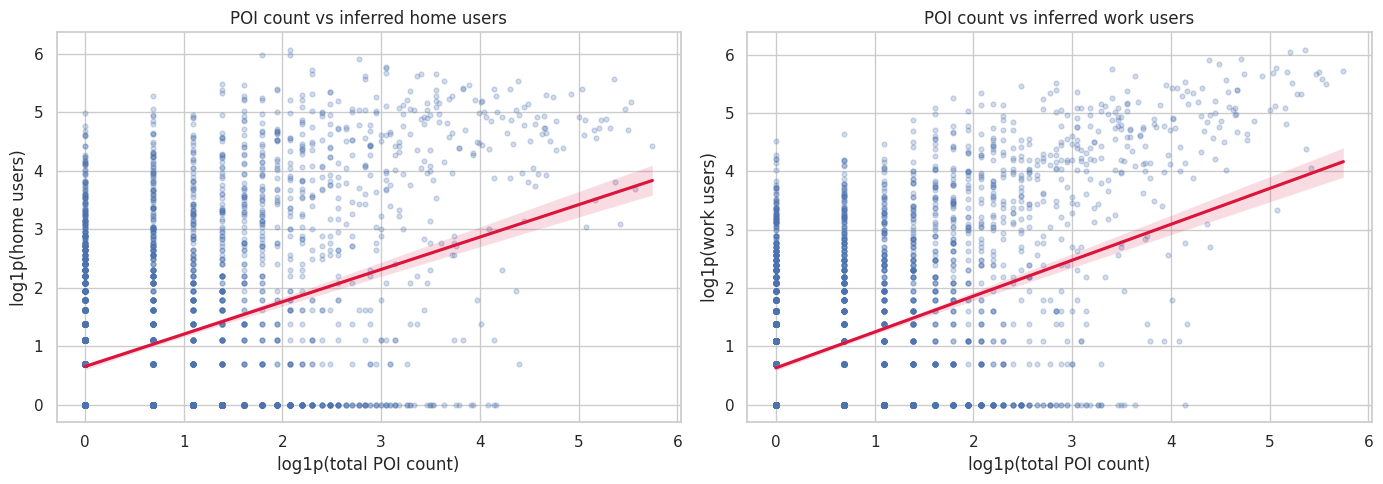

In [10]:
plot_df = cell_features.copy()
plot_df["log1p_home_users"] = np.log1p(plot_df["home_users"])
plot_df["log1p_work_users"] = np.log1p(plot_df["work_users"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.regplot(data=plot_df, x="log1p_total_poi_count", y="log1p_home_users", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "crimson"}, ax=axes[0])
axes[0].set_title("POI count vs inferred home users")
axes[0].set_xlabel("log1p(total POI count)")
axes[0].set_ylabel("log1p(home users)")

sns.regplot(data=plot_df, x="log1p_total_poi_count", y="log1p_work_users", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "crimson"}, ax=axes[1])
axes[1].set_title("POI count vs inferred work users")
axes[1].set_xlabel("log1p(total POI count)")
axes[1].set_ylabel("log1p(work users)")

plt.tight_layout()

In [11]:
display(cell_features.sort_values("home_users", ascending=False)[["h3_cell", "home_users", "work_users", "total_poi_count"]].head(15))
display(cell_features.sort_values("work_users", ascending=False)[["h3_cell", "home_users", "work_users", "total_poi_count"]].head(15))
display(cell_features.sort_values("total_poi_count", ascending=False)[["h3_cell", "home_users", "work_users", "total_poi_count"]].head(15))

,h3_cell,home_users,work_users,total_poi_count
1555,8830994855fffff,430,171,7
2130,883099580dfffff,394,210,7
2155,8830995847fffff,392,193,5
2281,8830995997fffff,371,209,15
2196,88309958b5fffff,324,136,20
2221,88309958edfffff,314,211,20
2125,8830995803fffff,305,132,9
1705,8830994a47fffff,288,160,20
2292,88309959b1fffff,285,175,34
1674,8830994a01fffff,284,314,29


,h3_cell,home_users,work_users,total_poi_count
2311,88309959dbfffff,260,438,212
2188,88309958a3fffff,113,420,181
2227,883099590bfffff,90,375,110
1707,8830994a4bfffff,251,371,79
1711,8830994a55fffff,169,345,88
3590,88309b96d9fffff,130,323,157
1674,8830994a01fffff,284,314,29
2306,88309959d1fffff,83,306,312
2299,88309959c1fffff,109,301,244
2224,8830995905fffff,95,298,175


,h3_cell,home_users,work_users,total_poi_count
2306,88309959d1fffff,83,306,312
2187,88309958a1fffff,39,244,262
2276,883099598bfffff,177,267,250
2299,88309959c1fffff,109,301,244
2305,88309959cdfffff,156,290,236
2277,883099598dfffff,21,57,224
2301,88309959c5fffff,44,79,213
2311,88309959dbfffff,260,438,212
2302,88309959c7fffff,113,206,203
2300,88309959c3fffff,132,207,194


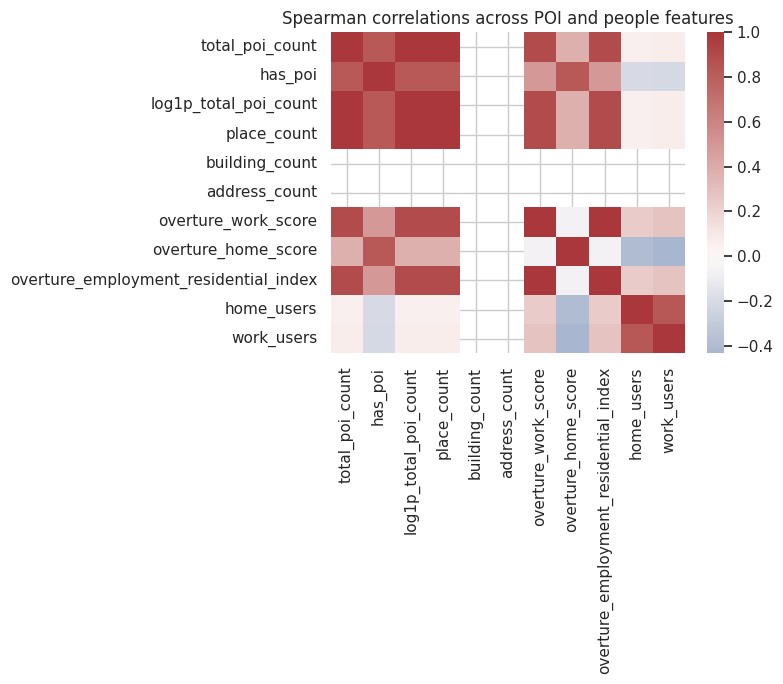

In [12]:
heatmap_features = base_features + optional_features[:20] + target_cols
heatmap_features = [c for c in heatmap_features if c in cell_features.columns]

if len(heatmap_features) >= 3:
    corr_matrix = cell_features[heatmap_features].corr(method="spearman")
    plt.figure(figsize=(max(8, len(heatmap_features) * 0.45), 7))
    sns.heatmap(corr_matrix, cmap="vlag", center=0, square=False)
    plt.title("Spearman correlations across POI and people features")
    plt.tight_layout()
else:
    print("Not enough numeric features for a heatmap.")

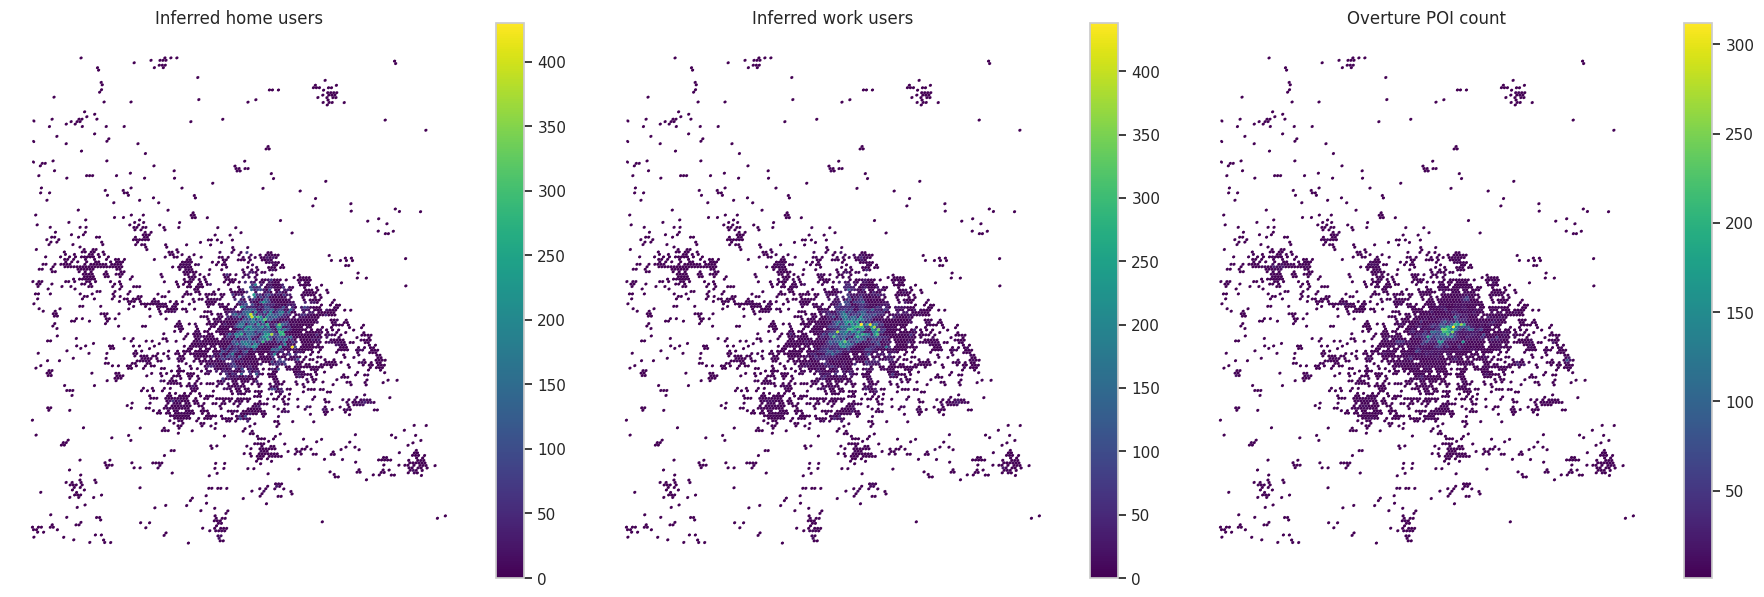

In [13]:
map_df = cell_features.dropna(subset=["cell_polygon_wkt"]).copy()
map_df["geometry"] = map_df["cell_polygon_wkt"].map(wkt.loads)
cell_gdf = gpd.GeoDataFrame(map_df, geometry="geometry", crs="EPSG:4326")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, column, title in [
    (axes[0], "home_users", "Inferred home users"),
    (axes[1], "work_users", "Inferred work users"),
    (axes[2], "total_poi_count", "Overture POI count"),
]:
    cell_gdf.plot(column=column, cmap="viridis", linewidth=0, legend=True, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()

## Interpretation Notes

- A positive POI/work correlation suggests Overture-dense cells tend to attract inferred work locations.
- A positive POI/home correlation suggests residential inference is concentrated near amenity or business density, or that the grid cell is mixed-use.
- A weak or negative POI/home correlation is plausible because Overture `places` mostly describes businesses and amenities, not residential buildings.
- Category-level correlations are only available when the optional Overture category cache has been created.
- Home and work labels are inferred from repeated timestamped observations. They should be interpreted as behavioral anchors, not survey-confirmed home or workplace addresses.

## HOME-WORK Distance Analysis

This section checks whether long simulated jump lengths may be driven by HOME and WORK anchors being too far apart. Observed HOME/WORK anchors use the same inferred cells as the EDA above. Simulated-anchor distances use the current POI+building profile-anchor logic without running trajectories.

In [14]:

from pathlib import Path
import os

from citybehavex.config import load_config
from citybehavex.profiles import generate_profiles
from citybehavex.simulation.runner import (
    _append_work_scores,
    _derive_home_anchor_candidates_from_tessellation,
    _load_or_build_tessellation_df,
)


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "configs").exists() and (candidate / "data").exists():
            return candidate
    return Path("../..").resolve()


def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))


def h3_latlng_frame(cells: pd.Series) -> pd.DataFrame:
    latlng = [h3.cell_to_latlng(str(cell)) for cell in cells]
    return pd.DataFrame(latlng, columns=["lat", "lon"])


def summarize_home_work_distances(city: str, source: str, distances_km: pd.Series | np.ndarray) -> dict:
    distances = pd.Series(distances_km, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    quantiles = distances.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95]) if len(distances) else pd.Series(dtype=float)
    return {
        "city": city,
        "source": source,
        "n_users": int(len(distances)),
        "mean_km": distances.mean(),
        "std_km": distances.std(),
        "median_km": quantiles.get(0.50, np.nan),
        "p10_km": quantiles.get(0.10, np.nan),
        "p25_km": quantiles.get(0.25, np.nan),
        "p75_km": quantiles.get(0.75, np.nan),
        "p90_km": quantiles.get(0.90, np.nan),
        "p95_km": quantiles.get(0.95, np.nan),
        "max_km": distances.max() if len(distances) else np.nan,
        "share_le_2km": distances.le(2).mean() if len(distances) else np.nan,
        "share_le_5km": distances.le(5).mean() if len(distances) else np.nan,
        "share_le_10km": distances.le(10).mean() if len(distances) else np.nan,
        "share_le_20km": distances.le(20).mean() if len(distances) else np.nan,
    }


def simulated_anchor_home_work_distances(config_rel_path: str, building_cache_rel_path: str) -> pd.DataFrame:
    project_root = find_project_root()
    building_cache = project_root / building_cache_rel_path
    if not building_cache.exists():
        print(
            f"Skipping simulated-anchor distances: missing {building_cache}. "
            "Build/fetch this Overture building feature cache before running this comparison."
        )
        return pd.DataFrame(columns=["uid", "home_tile", "work_tile", "home_work_km"])

    cwd = Path.cwd()
    os.chdir(project_root)
    try:
        config = load_config(config_rel_path)
        tessellation_df, relevance_column = _load_or_build_tessellation_df(config)
        tessellation_df, relevance_column = _append_work_scores(config, tessellation_df, relevance_column)
        anchors = _derive_home_anchor_candidates_from_tessellation(
            config,
            tessellation_df,
            relevance_column,
            config.simulation.agents,
        )

        lng_col = "lng" if "lng" in tessellation_df.columns else "lon"
        home_rows = pd.DataFrame({col: [pd.NA] * len(anchors) for col in tessellation_df.columns})
        home_rows["lat"] = anchors["lat"].to_numpy(dtype=float)
        home_rows[lng_col] = anchors["lng"].to_numpy(dtype=float)
        if "lng" in home_rows.columns and "lon" in home_rows.columns:
            home_rows["lon"] = home_rows["lng"]
        home_rows["tile_id"] = [f"home_anchor_{i + 1}" for i in range(len(anchors))]
        home_rows["category"] = "residential"
        home_rows["purpose"] = "HOME"
        if relevance_column in home_rows.columns:
            home_rows[relevance_column] = float(config.profiles.home_anchor_relevance)

        augmented = pd.concat([tessellation_df, home_rows], ignore_index=True)
        home_tile_pool = np.arange(len(tessellation_df), len(augmented), dtype=np.int64)
        profiles = generate_profiles(
            config.simulation.agents,
            config.profiles,
            np.random.default_rng(config.simulation.random_state),
            augmented,
            relevance_column,
            home_tile_pool=home_tile_pool,
        )
    finally:
        os.chdir(cwd)

    profile_tiles = pd.DataFrame(
        {
            "uid": [p.uid for p in profiles],
            "home_tile": [p.home_tile for p in profiles],
            "work_tile": [p.work_tile for p in profiles],
        }
    )
    home_xy = augmented.iloc[profile_tiles["home_tile"].to_numpy()][["lat", lng_col]].reset_index(drop=True)
    work_xy = augmented.iloc[profile_tiles["work_tile"].to_numpy()][["lat", lng_col]].reset_index(drop=True)
    profile_tiles["home_work_km"] = haversine_km(
        home_xy["lat"],
        home_xy[lng_col],
        work_xy["lat"],
        work_xy[lng_col],
    )
    return profile_tiles


def compare_home_work_distance_distributions(city: str, observed_df: pd.DataFrame, simulated_df: pd.DataFrame) -> pd.DataFrame:
    if observed_df.empty or simulated_df.empty:
        return pd.DataFrame()
    observed = observed_df["home_work_km"].dropna()
    simulated = simulated_df["home_work_km"].dropna()
    ks_result = stats.ks_2samp(observed, simulated) if len(observed) and len(simulated) else None
    return pd.DataFrame(
        [
            {
                "city": city,
                "observed_median_km": observed.median(),
                "simulated_median_km": simulated.median(),
                "sim_over_observed_median": simulated.median() / observed.median() if observed.median() else np.nan,
                "wasserstein_km": stats.wasserstein_distance(observed, simulated),
                "ks_statistic": ks_result.statistic if ks_result is not None else np.nan,
                "ks_pvalue": ks_result.pvalue if ks_result is not None else np.nan,
            }
        ]
    )

observed_home_work = home_cells.merge(work_cells, on="user_id", how="inner")
home_xy = h3_latlng_frame(observed_home_work["home_cell"])
work_xy = h3_latlng_frame(observed_home_work["work_cell"])
observed_home_work["home_work_km"] = haversine_km(home_xy["lat"], home_xy["lon"], work_xy["lat"], work_xy["lon"])

simulated_home_work = simulated_anchor_home_work_distances(
    "configs/shanghai_simulation.yaml",
    "data/shanghai/shanghai_overture_buildings_h3r9.parquet",
)

home_work_summary = pd.DataFrame(
    [summarize_home_work_distances("Shanghai", "observed", observed_home_work["home_work_km"])]
    + ([summarize_home_work_distances("Shanghai", "simulation_anchor_logic", simulated_home_work["home_work_km"])] if not simulated_home_work.empty else [])
)
home_work_comparison = compare_home_work_distance_distributions("Shanghai", observed_home_work, simulated_home_work)

display(home_work_summary.round(4))
if not home_work_comparison.empty:
    display(home_work_comparison.round(4))


Loading cached generated tessellation from data/shanghai/shanghai_h3_tessellation.parquet ...
Loading cached Overture building features from data/shanghai/shanghai_overture_buildings_h3r9.parquet ...
Using POI + Overture building work scores for profile work tiles
Loading cached Overture building features from data/shanghai/shanghai_overture_buildings_h3r9.parquet ...
Derived residential HOME anchors from POI + Overture building scores


,city,source,n_users,mean_km,std_km,median_km,p10_km,p25_km,p75_km,p90_km,p95_km,max_km,share_le_2km,share_le_5km,share_le_10km,share_le_20km
0,Shanghai,observed,52370,6.5488,8.7937,3.0649,0.8242,0.8539,8.5677,16.0840,23.8975,114.4116,0.4026,0.6098,0.7948,0.9301
1,Shanghai,simulation_anchor_logic,58501,4.3837,4.0303,3.3165,0.4786,1.4145,6.2090,9.7138,12.1702,43.7722,0.3343,0.6636,0.9082,0.9940


,city,observed_median_km,simulated_median_km,sim_over_observed_median,wasserstein_km,ks_statistic,ks_pvalue
0,Shanghai,3.0649,3.3165,1.0821,2.4669,0.1434,0.0


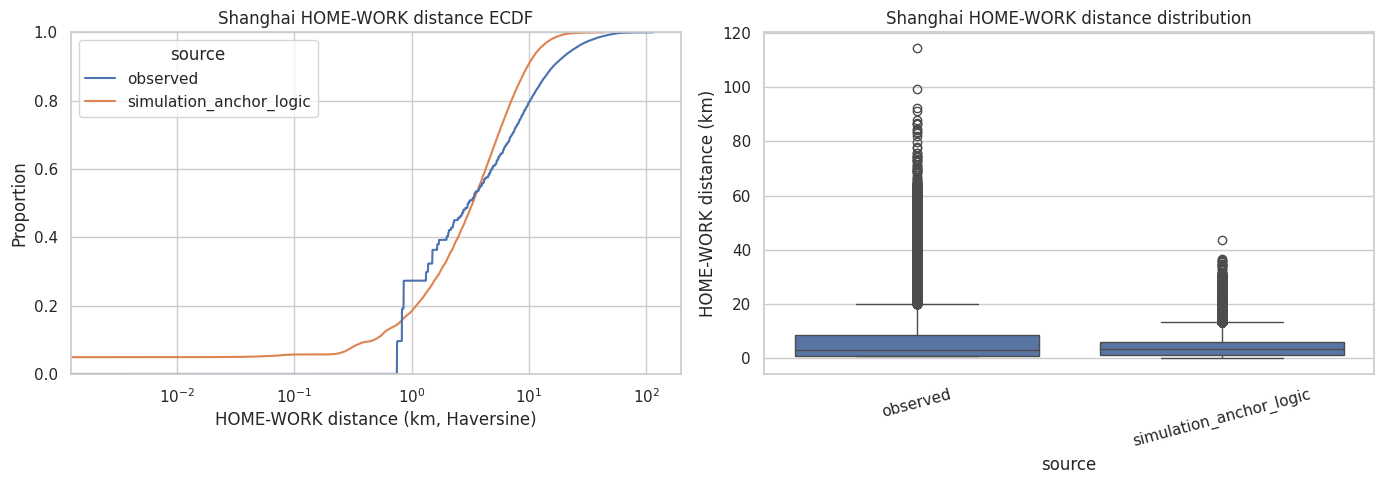

In [15]:

plot_parts = [observed_home_work.assign(source="observed")]
if not simulated_home_work.empty:
    plot_parts.append(simulated_home_work.assign(source="simulation_anchor_logic"))
home_work_plot = pd.concat(plot_parts, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.ecdfplot(data=home_work_plot, x="home_work_km", hue="source", ax=axes[0])
axes[0].set_title("Shanghai HOME-WORK distance ECDF")
axes[0].set_xlabel("HOME-WORK distance (km, Haversine)")
axes[0].set_xscale("log")

sns.boxplot(data=home_work_plot, x="source", y="home_work_km", ax=axes[1])
axes[1].set_title("Shanghai HOME-WORK distance distribution")
axes[1].set_ylabel("HOME-WORK distance (km)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()


### HOME-WORK Distance Interpretation

If `simulation_anchor_logic` has a much larger median or upper tail than `observed`, the profile anchor sampler is likely creating commutes that are too long before the mobility model even runs. These are direct Haversine distances between inferred HOME and WORK anchors, not road-network commute distances.